In [31]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import ast

df=pd.read_csv(r"C:\Users\SAMA\Downloads\data_jobs.csv")

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

def clean(skills):
    
    if pd.notna(skills):
        
        return ast.literal_eval(skills)
    
    else :
        
        return skills
    
df['job_skills']=df['job_skills'].apply(clean)  

In [32]:
df_DA_US=df[(df['job_country']=='United States')& (df['job_title_short']=='Data Analyst')].copy()
df_DA_US.dropna(subset='salary_year_avg',inplace=True)
df_DA_exploded=df_DA_US.explode('job_skills')

In [33]:
df_grouped=df_DA_exploded.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median=('salary_year_avg','median')
)
df_grouped.sort_values(by='skill_count',ascending=False,inplace=True)
df_grouped=df_grouped.rename(columns={'median':'median_salary'})

In [34]:

df_grouped

,skill_count,median_salary
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0
...,...,...
theano,1,100000.0
typescript,1,65000.0
vmware,1,147500.0


In [35]:
df_total=len(df_DA_US)
df_grouped['skill_percent']=(df_grouped['skill_count']/df_total)*100
df_grouped_high_demand=df_grouped[df_grouped['skill_percent']>5]

In [6]:
df_grouped_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


In [36]:
import seaborn as sns
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

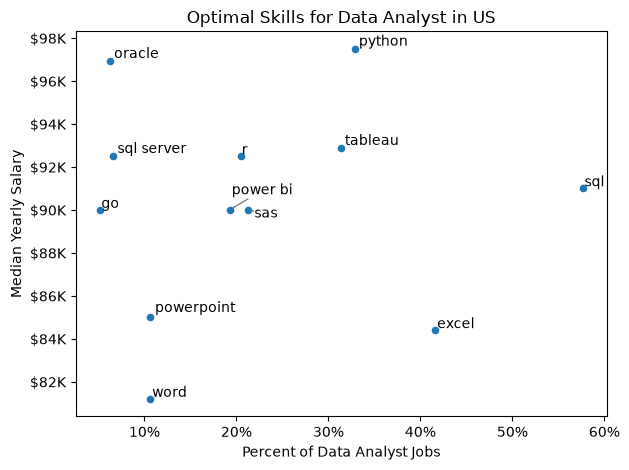

In [37]:
df_grouped_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')
texts = []
for i, txt in enumerate(df_grouped_high_demand.index):
    texts.append(plt.text(df_grouped_high_demand['skill_percent'].iloc[i], df_grouped_high_demand['median_salary'].iloc[i], txt))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title(f'Optimal Skills for Data Analyst in US')


ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [38]:
df_technology=df['job_type_skills'].copy()
df_technology=df_technology.drop_duplicates()
df_technology=df_technology.dropna()


In [39]:
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  
    for key, value in row_dict.items():
        if key in technology_dict:  
            technology_dict[key] += value
        else:                      
            technology_dict[key] = value

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

In [40]:
df_technology=pd.DataFrame(list(technology_dict.items()),columns=['technology','skills'])

In [41]:
df_technology=df_technology.explode('skills')

In [42]:
df_technology

,technology,skills
0,analyst_tools,nuix
0,analyst_tools,visio
0,analyst_tools,ssrs
0,analyst_tools,msaccess
0,analyst_tools,outlook
...,...,...
9,sync,zoom
9,sync,rocketchat
9,sync,google chat
9,sync,ringcentral


In [43]:
df_grouped_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


In [44]:
df_plot=df_grouped_high_demand.merge(df_technology,left_on='job_skills',right_on='skills')

In [45]:
df_plot

,skill_count,median_salary,skill_percent,technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,926,90000.00,21.287356,analyst_tools,sas
5,926,90000.00,21.287356,programming,sas
6,893,92500.00,20.528736,programming,r
7,838,90000.00,19.264368,analyst_tools,power bi
8,462,85000.00,10.620690,analyst_tools,powerpoint
9,461,81194.75,10.597701,analyst_tools,word


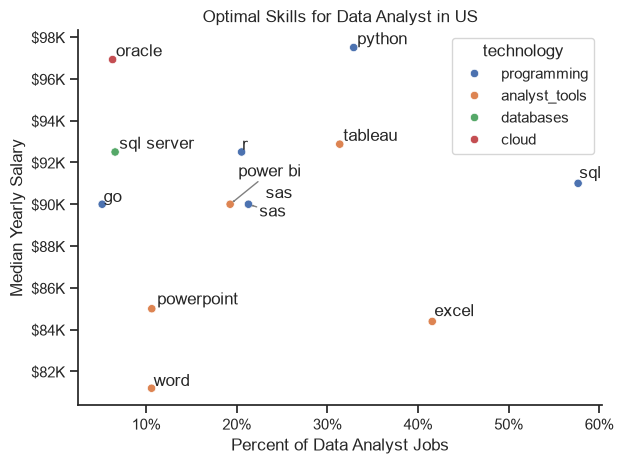

In [50]:
# df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')
sns.set_theme(style='ticks')
sns.scatterplot(df_plot,
                x='skill_percent',
                y='median_salary',
                hue='technology'
                )

texts = []
for i, txt in enumerate(df_plot['skills']):
    texts.append(plt.text(df_plot['skill_percent'].iloc[i], df_plot['median_salary'].iloc[i], txt))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

sns.despine()

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title(f'Optimal Skills for Data Analyst in US')


ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
# Adjust layout and display the plot
plt.tight_layout()
plt.show()